In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Read the dataset
df = pd.read_csv("../data/stroke_dataset.csv")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


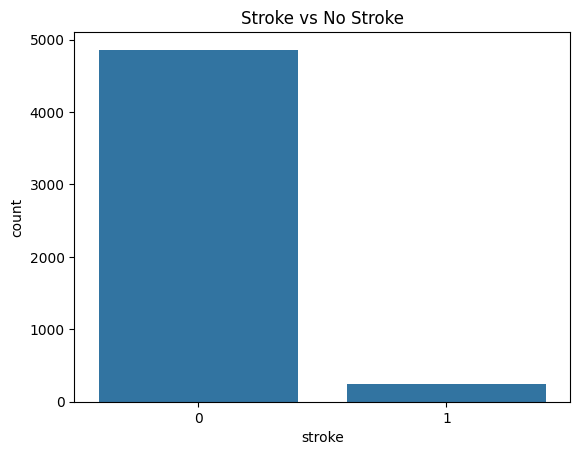

In [4]:
sns.countplot(x='stroke', data=df)
plt.title('Stroke vs No Stroke')
plt.savefig(f"../notebooks/images/stroke_no_stroke.png", bbox_inches="tight")
plt.show()

In [5]:
num_cols = ["age", "avg_glucose_level", "bmi"]
cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
bin_cols = ["hypertension", "heart_disease"]
all_cols= num_cols + cat_cols + bin_cols

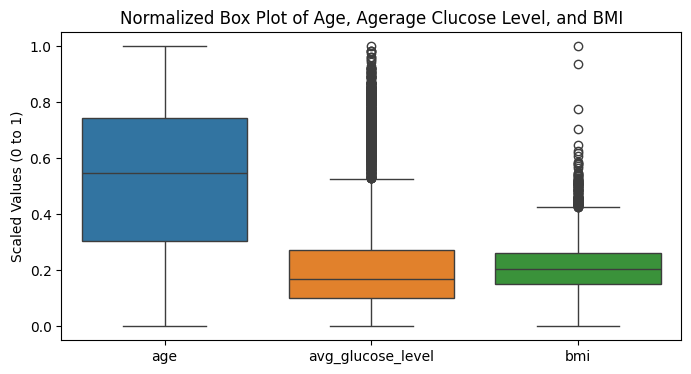

In [6]:
# Draw boxplots
# Help to identify outliers
# Identify 4 quartiles features
# Skewness, if median line is not centered, so mean is not equal to median
#Average Glucose level nad bmo has large number of outliers
# Select only numerical columns
df_numeric = df[num_cols]

# Apply Min-Max Scaling
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=num_cols)

# Plot boxplots
plt.figure(figsize=(8,4))
sns.boxplot(data=df_scaled)
plt.title("Normalized Box Plot of Age, Agerage Clucose Level, and BMI")
plt.ylabel("Scaled Values (0 to 1)")
plt.savefig(f"../notebooks/images/normalized_box_plot.png", bbox_inches="tight")
plt.show()

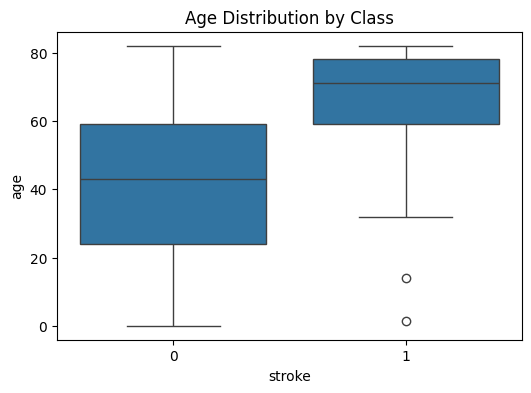

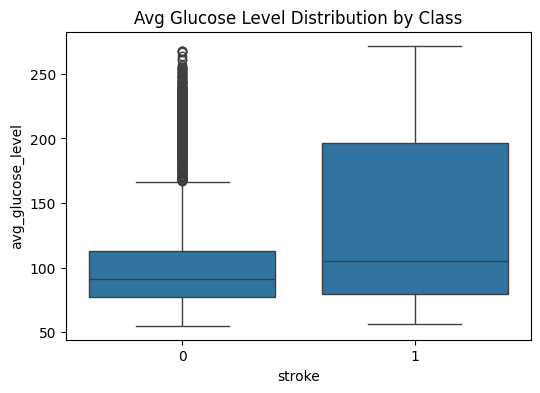

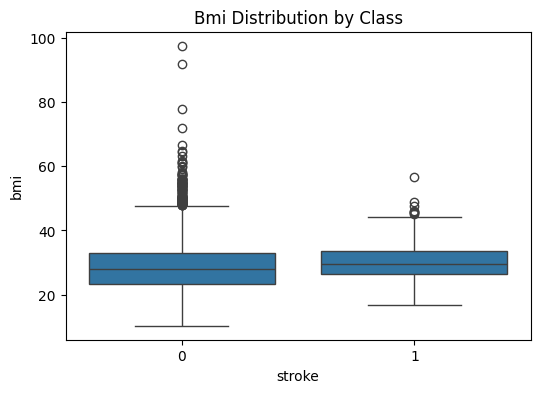

In [7]:
# Violin / Boxplots for Numeric Features by Stroke
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='stroke', y=col, data=df)
    col_name = col.replace("_", " ").title()
    plt.title(f'{col_name} Distribution by Class')
    plt.savefig(f"../notebooks/images/{col}_box_plot_by_class.png", bbox_inches="tight")
    plt.show()

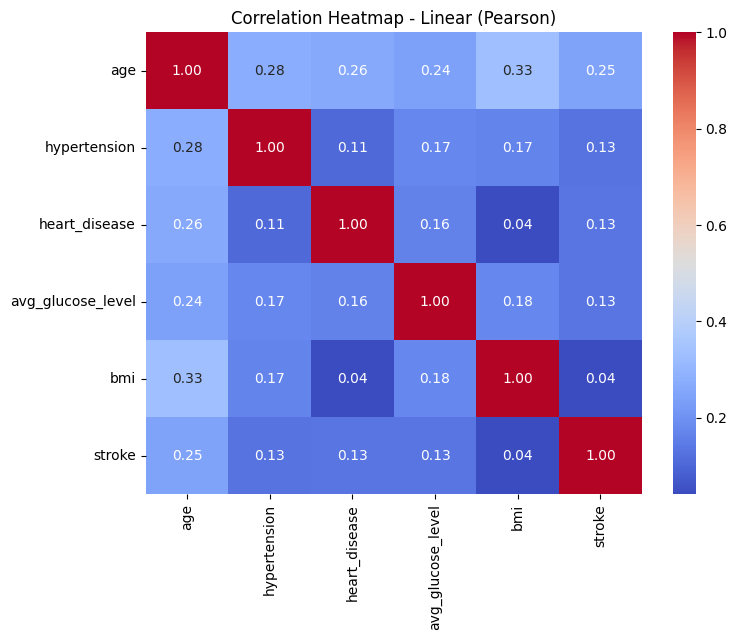

In [8]:
correlation_matrix = df[['age','hypertension','heart_disease','avg_glucose_level','bmi','stroke']].corr(method='pearson') # Compute the correlation matrix
#sns.heatmap() is used to visualize the correlation matrix
# Stroke is has weak linear correlation in order strong to weak: age, (hypertension, heart disease, avg glucose level), then bmi.
# All vriables have weak linear correlation with each other.
# Visualize the correlation matrix usign heat map.
plt.figure(figsize=(8, 6)) # Adjust plot size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f') # Create the heatmap
plt.title('Correlation Heatmap - Linear (Pearson)') # Add a title
plt.savefig(f"../notebooks/images/correlation_heatmap_linear.png", bbox_inches="tight")
plt.show() # Display the plot

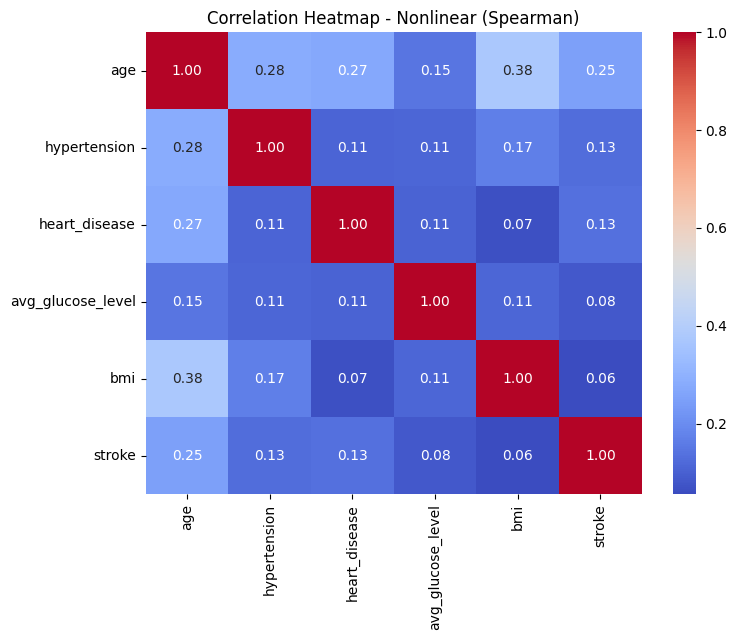

In [9]:
correlation_matrix = df[['age','hypertension','heart_disease','avg_glucose_level','bmi','stroke']].corr(method='spearman') # Compute the correlation matrix
#sns.heatmap() is used to visualize the correlation matrix
# Stroke is has weak linear correlation in order strong to weak: age, (hypertension, heart disease, avg glucose level), then bmi.
# All vriables have weak linear correlation with each other.
# Visualize the correlation matrix usign heat map.
plt.figure(figsize=(8, 6)) # Adjust plot size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f') # Create the heatmap
plt.title('Correlation Heatmap - Nonlinear (Spearman)') # Add a title
plt.savefig(f"../notebooks/images/correlation_heatmap_non_linear.png", bbox_inches="tight")
plt.show() # Display the plot

In [10]:
# Data cleaning (BMI has missing values; replacing them with the median)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [11]:
# Dropping the 'id' column as it has no predictive power
df_model = df.drop(columns=['id'])

In [12]:
# Encoding Categorical Variables (Since models require numerical input, converting strings (Gender, Smoking, etc.))
le = LabelEncoder()
categorical_cols = df_model.select_dtypes(include=['object']).columns # Identify all columns in the dataframe that contain string/categorical data (pandas type object)
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col]) # converts the unique categories into integers for each column.

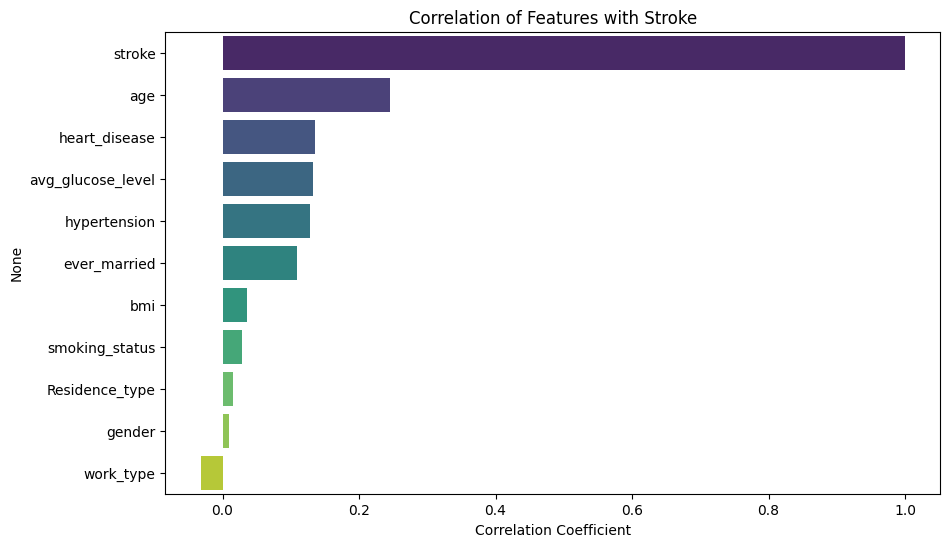

In [13]:
# Correlation Analysis : Compute the Pearson correlation coefficient between every numerical column in df_model and the 'stroke' column.
plt.figure(figsize=(10, 6))
correlation = df_model.corr()['stroke'].sort_values(ascending=False) # Sort the resulting correlation values in descending order
sns.barplot(x=correlation.values, y=correlation.index, palette='viridis', hue=correlation.index, legend=False)
plt.title('Correlation of Features with Stroke')
plt.xlabel('Correlation Coefficient')
plt.show()

In [14]:
# Feature Importance using Random Forest
X = df_model.drop('stroke', axis=1)
y = df_model['stroke']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

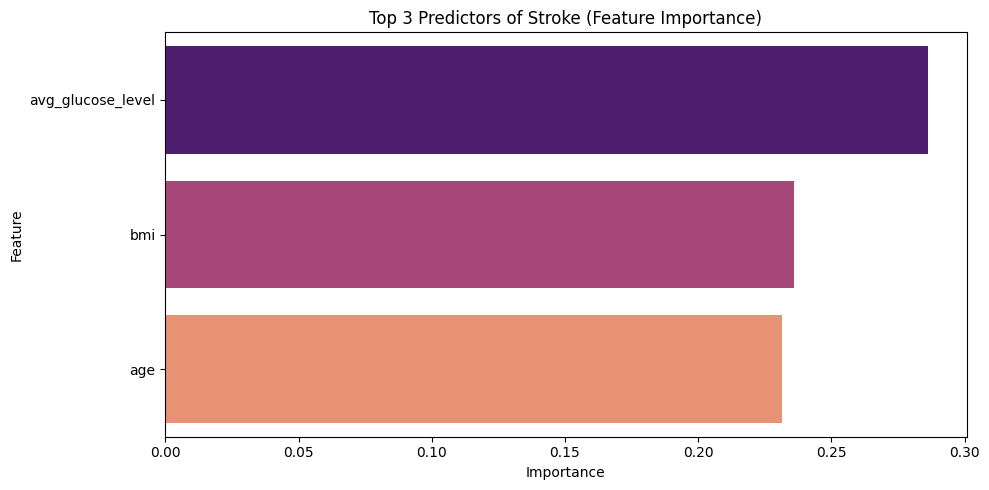

In [15]:
# Visualize Top 3 Predictors
plt.figure(figsize=(10, 5))
sns.barplot(data=importances.head(3), x='Importance', y='Feature', palette='magma', hue='Feature', legend=False)
plt.title('Top 3 Predictors of Stroke (Feature Importance)')
plt.tight_layout()
plt.savefig('../notebooks/images/top_3_predictors.png')

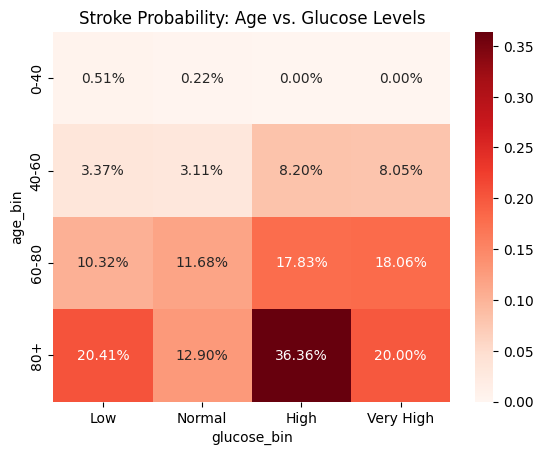

In [16]:
# Heatmap of Risk Age and Glucose
# Create age bins
df['age_bin'] = pd.cut(df['age'], bins=[0, 40, 60, 80, 100], labels=['0-40', '40-60', '60-80', '80+'])
# Create glucose bins
df['glucose_bin'] = pd.cut(df['avg_glucose_level'], bins=[0, 90, 140, 200, 300], labels=['Low', 'Normal', 'High', 'Very High'])

# Pivot table for heatmap
pivot = df.pivot_table(index='age_bin', columns='glucose_bin', values='stroke', aggfunc='mean', observed=False)

sns.heatmap(pivot, annot=True, cmap='Reds', fmt='.2%')
plt.title('Stroke Probability: Age vs. Glucose Levels')
plt.show()

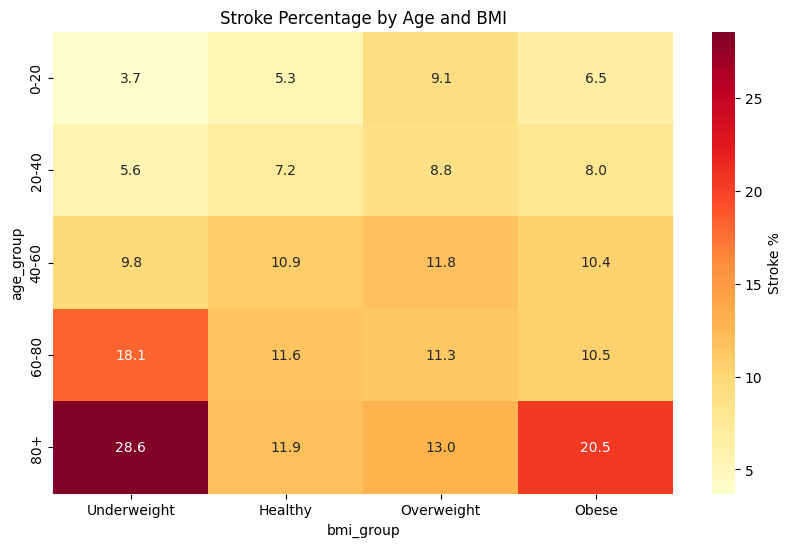

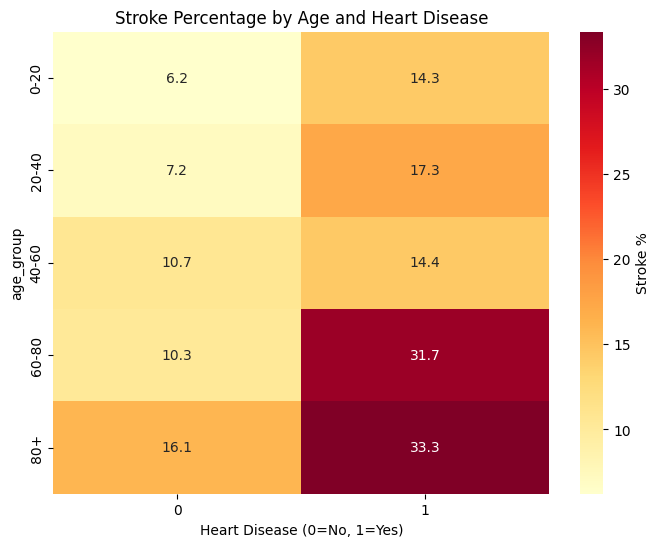

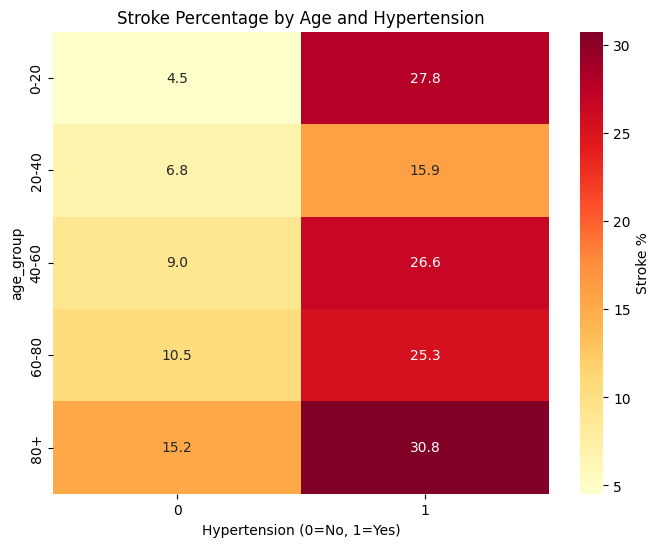

In [17]:
# Check the probability of incidence of stroke when compared against 2 factors

# Simulate Stroke Prediction Dataset for visualization purposes
np.random.seed(42)
n = 5110 # Typical size of the dataset
age = np.random.normal(43, 22, n).clip(0, 82)
bmi = np.random.normal(28, 7, n).clip(14, 60)
hypertension = np.random.choice([0, 1], n, p=[0.9, 0.1])
heart_disease = np.random.choice([0, 1], n, p=[0.95, 0.05])

# Stroke probability increases with age, hypertension, heart_disease, and glucose
# Simplified risk model for simulation
prob = (age / 82) * 0.1 + (hypertension * 0.15) + (heart_disease * 0.15) + (bmi / 60) * 0.05
stroke = np.array([1 if np.random.rand() < p else 0 for p in prob])

df = pd.DataFrame({
    'age': age,
    'bmi': bmi,
    'hypertension': hypertension,
    'heart_disease': heart_disease,
    'stroke': stroke
})

# 1. Binning Age
age_bins = [0, 20, 40, 60, 80, 100]
age_labels = ['0-20', '20-40', '40-60', '60-80', '80+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# 2. Binning BMI
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ['Underweight', 'Healthy', 'Overweight', 'Obese']
df['bmi_group'] = pd.cut(df['bmi'], bins=bmi_bins, labels=bmi_labels)

def get_stroke_pct(df, index_col, col_col):
    pivot = df.pivot_table(index=index_col, columns=col_col, values='stroke', aggfunc='mean', observed=False) * 100
    return pivot

# Age and BMI
plt.figure(figsize=(10, 6))
pct_age_bmi = get_stroke_pct(df, 'age_group', 'bmi_group')
sns.heatmap(pct_age_bmi, annot=True, fmt=".1f", cmap='YlOrRd', cbar_kws={'label': 'Stroke %'})
plt.title('Stroke Percentage by Age and BMI')
plt.show()

# Age and Heart Disease
plt.figure(figsize=(8, 6))
pct_age_hd = get_stroke_pct(df, 'age_group', 'heart_disease')
sns.heatmap(pct_age_hd, annot=True, fmt=".1f", cmap='YlOrRd', cbar_kws={'label': 'Stroke %'})
plt.title('Stroke Percentage by Age and Heart Disease')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.show()

# Age and Hypertension
plt.figure(figsize=(8, 6))
pct_age_hyp = get_stroke_pct(df, 'age_group', 'hypertension')
sns.heatmap(pct_age_hyp, annot=True, fmt=".1f", cmap='YlOrRd', cbar_kws={'label': 'Stroke %'})
plt.title('Stroke Percentage by Age and Hypertension')
plt.xlabel('Hypertension (0=No, 1=Yes)')
plt.show()

### Conclusion
- Correlation is low to moderate for both linear (pearson) and non linear (spearman)
- Stroke is mostly correlated with age, then average glucose level, hypertension, heart disease.
- Average glucose level, and bmi have lot of outlier mainly in Class 0 (non stroke)